In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import collections
import sys

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers, models, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from scikeras.wrappers import KerasClassifier
from google.colab import drive


In [ ]:
!pip install scikeras --upgrade

In [ ]:
drive.mount('/content/gdrive')
drivePath = ('/content/gdrive/MyDrive/projects/data')
sys.path.append(drivePath)
os.chdir(drivePath)
current_dir = os.getcwd()
current_dir

Mounted at /content/gdrive


'/content/gdrive/MyDrive/projects/data'

In [ ]:
data_dir = "/content/gdrive/MyDrive/projects/data"
image_size = 128
labels_map = {"White": 0, "Black": 1, "Asian": 2, "Indian": 3}

In [ ]:
# Fungsi untuk mengekstraksi fitur warna kulit
def extract_skin_color_feature(img):
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Menambahkan lebih banyak rentang untuk mendeteksi lebih banyak variasi kulit
    skin_ranges = [
        # Light to tan
        (np.array([0, 20, 70], dtype=np.uint8), np.array([20, 255, 255], dtype=np.uint8)),
        # Medium/darker
        (np.array([0, 30, 40], dtype=np.uint8), np.array([20, 200, 150], dtype=np.uint8)),
        # Very dark
        (np.array([0, 40, 20], dtype=np.uint8), np.array([25, 255, 100], dtype=np.uint8)),
        # Range for light skin tones (White/Indian)
        (np.array([0, 10, 50], dtype=np.uint8), np.array([10, 255, 255], dtype=np.uint8)),   # Very light skin
        # Additional range for darker tones
        (np.array([0, 40, 50], dtype=np.uint8), np.array([20, 255, 255], dtype=np.uint8)),   # Darker skin
    ]

    mask_total = np.zeros(img.shape[:2], dtype=np.uint8)
    for lower, upper in skin_ranges:
        mask = cv2.inRange(img_hsv, lower, upper)
        mask_total = cv2.bitwise_or(mask_total, mask)

    skin = cv2.bitwise_and(img, img, mask=mask_total)
    skin_pixels = skin[mask_total > 0]

    if len(skin_pixels) > 0:
        mean_skin_color = np.mean(skin_pixels, axis=0)  # [R, G, B]
    else:
        # fallback: pakai rata-rata seluruh gambar
        mean_skin_color = np.mean(img, axis=(0, 1))

    return mean_skin_color

# Memuat data dan preprocessing
print("\n🔄 Memuat data dan preprocessing...")

data = []
labels = []
skin_features = []

# Memeriksa distribusi gambar per label
label_counts = {label: 0 for label in labels_map.values()}

# Proses gambar dari dataset
for race_label in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, race_label)
    if not os.path.isdir(folder_path):
        continue

    label = labels_map.get(race_label)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path)

            # === DATA CLEANING ===
            if img is None:
                print(f"🧹 Gagal membaca gambar: {img_path}")
                continue
            if img.shape[0] < 50 or img.shape[1] < 50:
                print(f"🧹 Gambar terlalu kecil: {img_path}")
                continue
            if len(img.shape) != 3 or img.shape[2] != 3:
                print(f"🧹 Bukan gambar RGB: {img_path}")
                continue

            img = cv2.resize(img, (image_size, image_size))

            # === SKIN COLOR FEATURE EXTRACTION ===
            skin_color_feat = extract_skin_color_feature(img)
            skin_features.append(skin_color_feat)

            data.append(img)
            labels.append(label)

            # Update distribusi label
            label_counts[label] += 1

        except Exception as e:
            print(f"❌ Error loading {img_path}: {e}")

# Memeriksa distribusi label gambar
print(f"\nDistribusi label gambar: {label_counts}")

# Konversi arrays
X = np.array(data, dtype="float32") / 255.0
y = np.array(labels)
y = to_categorical(y, num_classes=4)
skin_features = np.array(skin_features, dtype="float32") / 255.0  # Normalisasi

print(f"✅ Total data setelah cleaning: {len(X)}")
print(f"✅ Bentuk fitur warna kulit: {skin_features.shape}")


🔄 Memuat data dan preprocessing...

Distribusi label gambar: {0: 2000, 1: 2000, 2: 2010, 3: 2000}
✅ Total data setelah cleaning: 8010
✅ Bentuk fitur warna kulit: (8010, 3)


In [ ]:
# Variabel untuk data dan label
X = []
y = []

# Ukuran gambar yang diresize
IMG_SIZE = 128

# Load dan praproses gambar
for label_name, label_id in labels_map.items():
    folder_path = os.path.join(data_dir, label_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Baca grayscale
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))       # Resize
            X.append(img)
            y.append(label_id)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

# Convert ke numpy array
X = np.array(X)
y = np.array(y)

# Tambah 1 channel untuk grayscale
if len(X.shape) == 3:
    X = X[..., np.newaxis]

# Normalisasi pixel ke 0-1
X = X / 255.0

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Buat CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(labels_map), activation='softmax')  # Output layer = 4 kelas
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Evaluasi model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('\nTest accuracy:', test_acc)

Shape X: (8010, 128, 128, 1)
Shape y: (8010,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.2979 - loss: 1.4558 - val_accuracy: 0.4139 - val_loss: 1.2921
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4464 - loss: 1.2361 - val_accuracy: 0.4794 - val_loss: 1.2040
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5776 - loss: 1.0161 - val_accuracy: 0.4388 - val_loss: 1.2608
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7134 - loss: 0.7385 - val_accuracy: 0.4738 - val_loss: 1.3764
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8617 - loss: 0.4042 - val_accuracy: 0.4775 - val_loss: 1.6887
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9524 - loss: 0.1796 - val_accuracy: 0.4856 - val_loss: 2.3326
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9827 - loss: 0.0817 - val_accuracy: 0.4757 - val_loss: 2.6511
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9917 - loss: 0.0443 - val_acc

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
# Reshape X to 2D for SMOTE and apply SMOTE
X_reshaped = X.reshape(X.shape[0], -1)
X_resampled, y_resampled = smote.fit_resample(X_reshaped, y)
# Reshape X back to its original shape
X = X_resampled.reshape(-1, image_size, image_size, 1)  # Assuming grayscale images
# If you have RGB images (3 channels), change the reshape to:
# X = X_resampled.reshape(-1, image_size, image_size, 3)

# One-hot encode y
y = to_categorical(y_resampled, num_classes=4)

In [ ]:
from sklearn.utils import class_weight
y_int = np.argmax(y, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_int),
    y=y_int
)
class_weight_dict = dict(enumerate(class_weights))

In [ ]:
X = np.array(data)
y = to_categorical(labels, num_classes=4)

# Cek keseimbangan label
print("\n📊 Distribusi Label:")
print(collections.Counter(np.argmax(y, axis=1)))



📊 Distribusi Label:
Counter({np.int64(2): 2010, np.int64(3): 2000, np.int64(1): 2000, np.int64(0): 2000})


In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Augmentasi Data
train_datagen = ImageDataGenerator(
     rotation_range=15,
     width_shift_range=0.5,
     height_shift_range=0.5,
     shear_range=0.2,
     zoom_range=[0.8, 1.2],
     horizontal_flip=True,
     brightness_range=[0.7, 1.3],
     fill_mode='nearest'
 )

#The line causing the error was over-indented. It should be aligned with the train_datagen assignment.
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def create_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(image_size, image_size, 3)))

    # Freeze layers in the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # ResNet biasanya lebih cocok pakai GlobalAveragePooling
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(4, activation='softmax')(x)

    # Create the final model
    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_int = np.argmax(y, axis=1)  # balik ke label integer

cv_results = []
for train_index, test_index in skf.split(X[:500], y_int[:500]):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y_int[train_index], y_int[test_index]

    # Create a new model instance for each fold
    model = create_model()

    model.fit(X_train_cv, to_categorical(y_train_cv, num_classes=4))  # Fit the model
    y_pred_cv = model.predict(X_test_cv)

    # Convert y_pred_cv to class labels before calculating accuracy
    y_pred_classes = np.argmax(y_pred_cv, axis=1)
    cv_results.append(accuracy_score(y_test_cv, y_pred_classes))

print("\n📊 Cross-validation scores:", cv_results)
print(f"📈 Rata-rata akurasi CV: {np.mean(cv_results):.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1090']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 274ms/step - accuracy: 0.8252 - loss: 0.5719


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1090']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1269']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1806']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.8179 - loss: 0.5484


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1806']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

📊 Cross-validation scores: [1.0, 1.0, 1.0, 1.0, 1.0]
📈 Rata-rata akurasi CV: 1.0000


In [ ]:
# Early Stopping
earlystop = EarlyStopping(patience=5, restore_best_weights=True)

# Calculate class weights
from sklearn.utils import class_weight
y_train_int = np.argmax(y_train, axis=1) # Convert one-hot encoded labels to integers
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights)) # Convert to dictionary

# Training
# Pass X_train and y_train separately for KerasClassifier with generator
history = model.fit(
    X_train, y_train,
    epochs=70,
    validation_data=(X_test, y_test),
    callbacks=[earlystop],
    class_weight=class_weight_dict
)

# Evaluasi
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n📈 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=labels_map.keys()))

print("\n🧩 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

Epoch 1/70


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1806']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


201/201 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.3298 - loss: 6.7373 - val_accuracy: 0.5462 - val_loss: 1.1442
Epoch 2/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4716 - loss: 1.1795 - val_accuracy: 0.5668 - val_loss: 1.0503
Epoch 3/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.5233 - loss: 1.1020 - val_accuracy: 0.5955 - val_loss: 1.0040
Epoch 4/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.5535 - loss: 1.0354 - val_accuracy: 0.6086 - val_loss: 0.9666
Epoch 5/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.5796 - loss: 1.0028 - val_accuracy: 0.6042 - val_loss: 0.9585
Epoch 6/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6148 - loss: 0.9459 - val_accuracy: 0.6336 - val_loss: 0.9134
Epoch 7/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6160 - loss: 0.9284 - val_accuracy: 0.6317 - val_loss: 0.9188
Epoch 8/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6258 - loss: 0.9029 - val_accuracy: 0.

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Create a new model instance for final training
final_model = create_model()

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=70,
    batch_size=32,
    callbacks=[early_stop]
)
loss, acc = final_model.evaluate(X_test, y_test)
print(f"\n🎯 Test Accuracy: {acc:.4f}")

y_pred = final_model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n🧾 Classification Report:")
print(classification_report(y_true, y_pred_labels, target_names=labels_map.keys()))

Epoch 1/70


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1985']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)


201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step - accuracy: 0.4172 - loss: 1.6435 - val_accuracy: 0.5724 - val_loss: 1.0234
Epoch 2/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5640 - loss: 1.0553 - val_accuracy: 0.6042 - val_loss: 0.9329
Epoch 3/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.6043 - loss: 0.9381 - val_accuracy: 0.5899 - val_loss: 0.9627
Epoch 4/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6272 - loss: 0.9052 - val_accuracy: 0.6223 - val_loss: 0.9128
Epoch 5/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6569 - loss: 0.8424 - val_accuracy: 0.6323 - val_loss: 0.8810
Epoch 6/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6691 - loss: 0.8313 - val_accuracy: 0.6236 - val_loss: 0.9035
Epoch 7/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6888 - loss: 0.7774 - val_accuracy: 0.6242 - val_loss: 0.8984
Epoch 8/70
201/201 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7025 - loss: 0.7300 - val_accuracy: 

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1985']
Received: inputs=Tensor(shape=(32, 128, 128, 3))
  warnings.warn(msg)


51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step

🧾 Classification Report:
              precision    recall  f1-score   support

       White       0.74      0.58      0.65       375
       Black       0.65      0.66      0.66       411
       Asian       0.64      0.63      0.63       394
      Indian       0.56      0.66      0.61       422

    accuracy                           0.64      1602
   macro avg       0.65      0.63      0.64      1602
weighted avg       0.64      0.64      0.64      1602



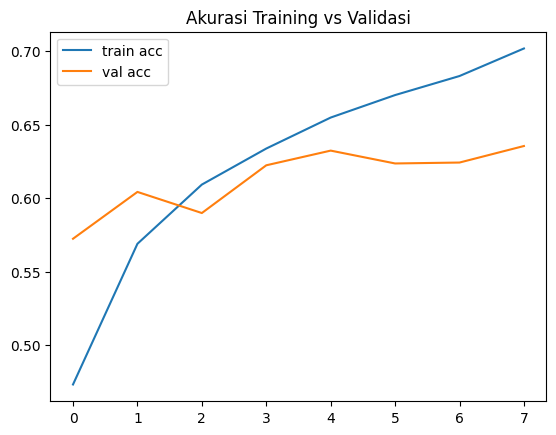

In [ ]:
# Plot Akurasi
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Akurasi Training vs Validasi')
plt.show()


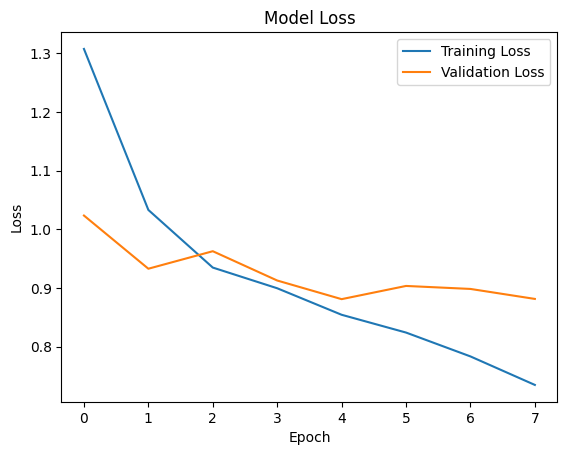

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = final_model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred_labels)

# Now you can calculate accuracy per class
accuracy_per_class = cm.diagonal() / cm.sum(axis=1)
label_names = list(labels_map.keys())
for i, acc in enumerate(accuracy_per_class):
    print(f"Akurasi kelas {label_names[i]}: {acc:.2%}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
Akurasi kelas White: 58.40%
Akurasi kelas Black: 65.94%
Akurasi kelas Asian: 62.94%
Akurasi kelas Indian: 66.35%


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


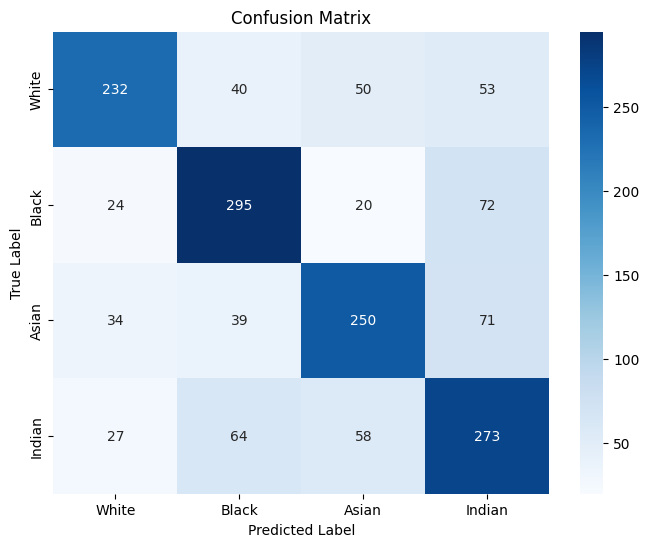

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Mengambil kelas dengan probabilitas tertinggi
y_true = np.argmax(y_test, axis=1)  # Mengambil kelas sebenarnya
cm = confusion_matrix(y_true, y_pred_classes)

# Tampilkan confusion matrix menggunakan seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_map.keys(), yticklabels=labels_map.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save('/content/gdrive/MyDrive/projects/model1_cnn.h5')